In [ ]:
import os
import shutil
import multiprocessing
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import astropy.constants as c
from scipy.ndimage import gaussian_filter, generic_filter
from q3dfit.q3din import q3din
from q3dfit.q3dout import q3dout, load_q3dout
from q3dfit.q3df import q3dfit
from q3dfit import q3dutil
from q3dfit.checkcomp import checkcomp
from q3dfit.q3dcollect import q3dcollect
from q3dfit.linelist import linelist
from gco.pygco import cut_grid_graph_simple  # https://pypi.org/project/gco-wrapper/

In [2]:
# helpers
c_kms = c.c.to("km/s").value

def makedir(*dirs):
    for d in dirs:
        if not os.path.exists(d):
            os.makedirs(d)

def micron_to_redshift(l, l0):
    return l/l0 - 1 

In [3]:
ncores = 22

In [5]:
def init_n_gauss_fit(
        n :int, 
        infile: str, 
        label: str, 
        lines: list[str],
        outdir: str,
        redshift: float, 
        fitrange: list[float]
        ) -> q3din:
#
    assert n > 0, f"n={n}: n must be a positive integer"
    assert os.path.exists(infile), f"{infile} doesn't exist"

    line_wavelengths = list(linelist(lines)["lines"]) # micron

    # create directories
    indir = os.path.join(outdir, "input")
    outdir_ = lambda n: os.path.join(outdir, f"output_comp{n}")
    logdir_ = lambda n: os.path.join(outdir, f"logfiles_comp{n}")
    makedir(indir, outdir_(n), logdir_(n))

    # create q3di object and set important parameters
    logfile = os.path.join(logdir_(n), label+"-fitlog.txt")
    q3di = q3din(infile, label, outdir=outdir_(n), logfile=logfile)
    q3di.argsreadcube = {"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}
    cube = q3di.load_cube()
    q3di.name = label
    q3di.zsys_gas = redshift
    q3di.fitrange = fitrange

    # line fit
    q3di.init_linefit(lines, linetie=lines[0], maxncomp=n, checkcomp=False)
    q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
    q3di.siglim_gas = np.array([40., 1000.])
    q3di.argslinefit['method'] = 'least_squares'
    q3di.argslinefit['ftol'] = 1.e-8
    q3di.argslinefit['gtol'] = 1.e-8
    q3di.argslinefit['xtol'] = 1.e-8
    q3di.argslinefit['x_scale'] = 'jac'
    q3di.argslinefit['tr_solver'] = 'lsmr'

    q3di.argscheckcomp['sigcut'] = 3.
    q3di.perror_useresid = True
    q3di.snr = 3.0

    for line in lines:
        q3di.siginit_gas[line][:,:,:] = 200.
        
    # line fit inital parameters for n>1
    if n > 1:
        previous_data = np.load(os.path.join(outdir_(n-1), label+".line.npz"), allow_pickle=True)

        for line, w in zip(lines, line_wavelengths):
            for i in range(n-1):
                init_val = micron_to_redshift(previous_data["emlwav"][None][0][f"c{i+1}"][line], w)
                q3di.zinit_gas[line][:,:,i][~np.isnan(init_val)] = init_val[~np.isnan(init_val)]
                init_sig = np.clip(previous_data["emlsig"][None][0][f"c{i+1}"][line], *q3di.siglim_gas)
                q3di.siginit_gas[line][:,:,i][~np.isnan(init_sig)] = init_sig[~np.isnan(init_sig)]

        res_data = np.load(os.path.join(outdir_(n-1), "max_res.npy"))
        res_val = micron_to_redshift(res_data, line_wavelengths[0])
        q3di.zinit_gas[lines[0]][:,:,n-1][~np.isnan(res_val)] = res_val[~np.isnan(res_val)]

    # continum fit
    q3di.init_contfit("fitpoly")
    q3di.argscontfit.update({"fitord": 1})
    q3di.maskwidths_def = 2000
    q3di.masksig_secondfit = 4

    q3di.filename = os.path.join(indir, f"q3di_{label}_{n}.npy")
    np.save(q3di.filename, q3di)
    return q3di

In [6]:
def get_max_residual(q3do: q3dout, q3di: q3din) -> tuple[float, float]:
    if hasattr(q3do, "cont_fit"):
        res = q3do.spec - q3do.cont_fit - q3do.line_fit
    else:
        res = q3do.spec - q3do.line_fit
    
    line = q3di.lines[0]
    wavedata = q3do.line_fitpars["wave"]
    sigmadata = q3do.line_fitpars["sigma"]
    index_min = np.argmin(wavedata[line].data)
    index_max = np.argmax(wavedata[line].data)
    peak_min = wavedata[line].data[index_min]
    peak_max = wavedata[line].data[index_max]
    width_min = sigmadata[line].data[index_min]
    width_max = sigmadata[line].data[index_max]
    # determine index of max residual within n-sigma of peak
    sig = 3
    mask = (q3do.wave >= peak_min * (1 - sig*width_min / c_kms)) & (q3do.wave <= peak_max * (1 + sig*width_max / c_kms))
    valid_indices = np.where(mask)[0]
    if len(valid_indices) > 0:
        sub_arr = res[mask]
        sub_idx = np.argmax(sub_arr)
        max_idx = valid_indices[sub_idx]
        max_res = q3do.wave[max_idx]
    else:
        max_res = np.nan

    if hasattr(q3do, "bic"):
        ic = q3do.bic
    else:
        ic = np.nan

    return max_res, ic

In [7]:
def fluxcutbic_check(
        ispax: int, 
        colarr: list[int], 
        rowarr: list[int], 
        q3di: q3din, 
        quiet: bool, 
        previous_bic: np.ndarray
        ) -> None | tuple[float, float]:
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do: q3dout = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        return
    if not q3do.dolinefit:
        return
    if q3di.docontfit:
        snr_resids = q3do.spec - q3do.cont_fit
    else:
        snr_resids = q3do.spec
    if q3do.ct_indx is None:
        return
    snr_resids = snr_resids[~q3do.ct_indx]
    noise = np.nanstd(snr_resids)
    min_flx = noise * q3di.snr

    current_bic = q3do.bic
    delta_bic = previous_bic[q3do.maxncomp - 1, i, j] - current_bic

    if (q3do.line_fitpars["fluxpk"][q3di.lines[0]].min() < min_flx) or (delta_bic < 6):
        if not quiet and (q3do.line_fitpars["fluxpk"][q3di.lines[0]].min() < min_flx):
            print(q3do.line_fitpars["fluxpk"][q3di.lines[0]].min())
            print(f"Discard [{int(i+1)}, {int(j+1)}] due to sigma cut")
        if not quiet and (delta_bic < 6):
            print(f"Discard [{int(i+1)}, {int(j+1)}] due to bic")
        q3do.discard = True
        np.save(q3do.filelab, q3do)
        return
    else:
        q3do.discard = False
        np.save(q3do.filelab, q3do)
        return get_max_residual(q3do, q3di)
    

In [8]:
def check_significance(
        q3di: q3din, 
        comp_map: np.ndarray,
        bic_array: np.ndarray,
        cols: list[int] | None = None, 
        rows: list[int] | None = None, 
        quiet: bool = True, 
        ncores: int = ncores
        ) -> tuple[np.ndarray, np.ndarray]:
    cube, vormap = q3dutil.get_Cube(q3di)
    nspax, colarr, rowarr = q3dutil.get_spaxels(cube, cols, rows)

    check_partial = partial(fluxcutbic_check, colarr=colarr, rowarr=rowarr, q3di=q3di, quiet=quiet, previous_bic=bic_array)

    max_res_array = np.full((cube.ncols, cube.nrows), np.nan, dtype="float64")

    with multiprocessing.Pool(ncores) as pool:
        results = pool.map(check_partial, range(0, nspax))
        for ispax, result in zip(range(0, nspax), results):
            if result is not None:
                max_res, aic = result
                i = colarr[ispax]
                j = rowarr[ispax]
                bic_array[q3di.maxncomp, i, j] = aic
                max_res_array[i, j] = max_res
                comp_map[q3di.maxncomp, i, j] = q3di.maxncomp
    # for ispax in range(0, nspax):
    #     check_partial(ispax)
    if not quiet:
        print("Check done.")
    np.save(os.path.join(q3di.outdir, "max_res.npy"), max_res_array)
    return comp_map, bic_array


In [9]:
def fit_n(n, infile, label, lines, outdir, redshift, fitrange):
    print("=== Setup ===")
    q3di = init_n_gauss_fit(n, infile, label, lines, outdir, redshift, fitrange)
    if n == 1:
        comp_map = np.zeros((10, q3di.ncols, q3di.nrows))
        bic = np.full((10, q3di.ncols, q3di.nrows), np.nan, dtype="float64")
    else:
        comp_map = np.load(os.path.join(outdir, "noc.npy"))
        bic = np.load(os.path.join(outdir, "bic.npy"))
    cols, rows = np.where(comp_map.max(axis=0) >= n-1)
    cols, rows = cols.tolist(), rows.tolist()

    print("===  Fit  ===")
    q3dfit(q3di.filename, cols, rows, onefit=True, quiet=True, ncores=ncores, nocrash=True)

    print("=== Check ===")
    comp_map, bic = check_significance(q3di, comp_map, bic, cols, rows, quiet=True)
    q3dcollect(q3di.filename, cols, rows, compsortpar="wave", quiet=True)

    plt.imshow(comp_map.max(axis=0).T, origin="lower")
    plt.colorbar()
    np.save(os.path.join(outdir, "noc.npy"), comp_map)
    np.save(os.path.join(outdir, "bic.npy"), bic)

In [10]:
# data = {
#     "infile": "4C1971_convolved.fits",
#     "label": "4C1971",
#     "lines": ,
#     "outdir": ,
#     "redshift": 3.5892,
#     "fitrange":
# }

# infile = "4C1971_G235H_NRS1_NRS2_s3d.fits"
# infile = "4C1971_convolved.fits"
# label = "4C1971"
# redshift = 3.5892
# lines = ["[OIII]5007", "[OIII]4959", "Hbeta"]
# outdir = "OIII"
# fitrange = [2.16, 2.375]

OIII_data = {
    "infile": "4C1971_convolved.fits",
    "label": "4C1971",
    "lines": ["[OIII]5007", "[OIII]4959", "Hbeta"],
    "outdir": "OIII",
    "redshift": 3.5892,
    "fitrange": [2.16, 2.375]
}

Halpha_data = {
    "infile": "4C1971_convolved.fits",
    "label": "4C1971",
    "lines": ["Halpha", "[NII]6548", "[NII]6583"],
    "outdir": "Halpha",
    "redshift": 3.5892,
    "fitrange": [2.95, 3.06]
}

SII_data = {
    "infile": "4C1971_convolved.fits",
    "label": "4C1971",
    "lines": ["[SII]6716", "[SII]6731"],
    "outdir": "SII",
    "redshift": 3.5892,
    "fitrange": [3.04, 3.14]
}

NeIII_data = {
    "infile": "4C1971_convolved.fits",
    "label": "4C1971",
    "lines": ["[NeIII]3869"],
    "outdir": "NeIII",
    "redshift": 3.5892,
    "fitrange": [1.74, 1.82]
}

OII_data = {
    "infile": "4C1971_convolved.fits",
    "label": "4C1971",
    "lines": ["[OII]3726", "[OII]3729"],
    "outdir": "OII",
    "redshift": 3.5892,
    "fitrange": [1.67, 1.73]
}

input_dict = OII_data

fit = partial(fit_n, **input_dict)

=== Setup ===
Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
===  Fit  ===
Core 2: # spaxels fit=264
Core 11: # spaxels fit=265
Core 4: # spaxels fit=264
Core 3: # spaxels fit=264
Core 8: # spaxels fit=264
Core 7: # spaxels fit=264
Core 9: # spaxels fit=264
Core 1: # spaxels fit=264
Core 18: # spaxels fit=264
Core 21: # spaxels fit=264
Core 13: # spaxels fit=264
Core 16: # spaxels fit=264
Core 22: # spaxels fit=265
Core 12: # spaxels fit=264
Core 5: # spaxels fit=264
Core 17: # spaxels fit=264
Core 6: # spaxels fit=264
Core 15: # spaxels fit=264
Core 20: # spaxels fit=264
Core 10: # spaxels fit=264
Core 14: # spaxels fit=264
Core 19: # spaxels fit=264
=== Check ===
Sorting components by wave in the upward

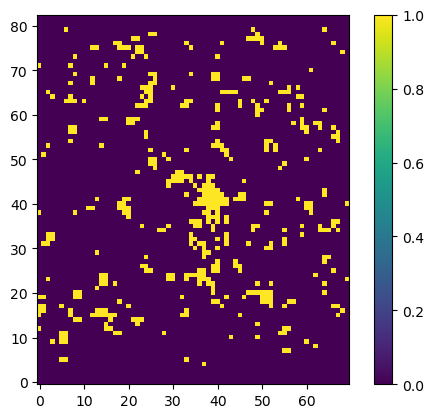

In [61]:
fit(1)

=== Setup ===
Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
===  Fit  ===
Core 5: # spaxels fit=21
Core 10: # spaxels fit=21
Core 1: # spaxels fit=21
Core 16: # spaxels fit=21
Core 11: # spaxels fit=21
Core 13: # spaxels fit=21
Core 20: # spaxels fit=21
Core 21: # spaxels fit=21
Core 17: # spaxels fit=21
Core 12: # spaxels fit=21
Core 8: # spaxels fit=21
Core 4: # spaxels fit=21
Core 7: # spaxels fit=21
Core 6: # spaxels fit=21
Core 14: # spaxels fit=21
Core 15: # spaxels fit=21
Core 18: # spaxels fit=21
Core 9: # spaxels fit=21
Core 19: # spaxels fit=21
Core 3: # spaxels fit=21
Core 2: # spaxels fit=21
Core 22: # spaxels fit=21
=== Check ===
Sorting components by wave in the upward direction.
        No

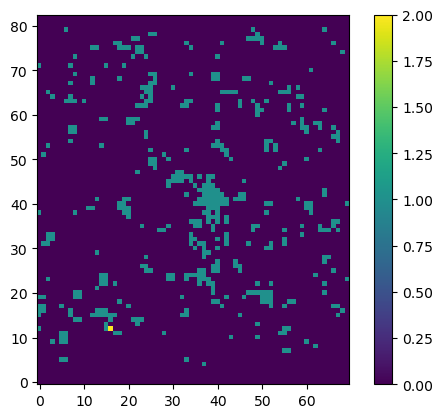

In [62]:
fit(2)

In [ ]:
fit(3)

In [ ]:
fit(4)

In [ ]:
fit(5)

In [ ]:
def combine_fit_results(infile, label, lines, outdir, redshift, fitrange):
    outdir_final = os.path.join(outdir, "output_combined")
    makedir(outdir_final)
    for file in os.listdir(outdir_final):
        os.unlink(os.path.join(outdir_final, file))

    ncomp_map = np.load(os.path.join(outdir, "noc.npy")).max(axis=0)
    # copy files
    it = np.nditer(ncomp_map, flags=["multi_index"])
    for i, x in enumerate(it):
        if x == 0:
            continue
        file = label+f"_{it.multi_index[0]+1:04d}_{it.multi_index[1]+1:04d}.npy"
        src = os.path.join(outdir, f"output_comp{int(x)}", file)
        try:
            shutil.copy2(src, outdir_final)
        except FileExistsError:
            ...
    
    q3di = q3din(infile, label, argsreadcube={"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}, outdir=outdir_final)
    q3di.name = label
    q3di.zsys_gas = redshift
    q3di.fitrange = fitrange
    cube = q3di.load_cube()
    q3di.init_linefit(lines, linetie=lines[0], maxncomp=int(np.nanmax(ncomp_map)))
    q3di.init_contfit("fitpoly")
    q3dcollect(q3di, compsortpar="flux")

In [63]:
combine_fit_results(**input_dict)

Cube: No wavelength units in header; using micron
Cube: Flux units in header (BUNIT) differ from fluxunit_in=MJy/sr; ignoring BUNIT. To override, set usebunit=True.
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: MJy/sr
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
Sorting components by flux in the upward direction.
        No data for [1, 1]
        No data for [1, 2]
        No data for [1, 3]
        No data for [1, 4]
        No data for [1, 5]
        No data for [1, 6]
        No data for [1, 7]
        No data for [1, 8]
        No data for [1, 9]
        No data for [1, 10]
        No data for [1, 11]
        No data for [1, 12]
        No data for [1, 14]
        No data for [1, 15]
        No data for [1, 19]
        No data for [1, 21]
        No data for [1, 22]
        No data for [1, 23]
        No data

In [11]:
def gaussian_rounding(data, sigma=1.0):
    smoothed = gaussian_filter(data.astype(float), sigma=sigma)
    return np.round(smoothed).astype(int)

def mode_filter(data, size=3):
    def mode_func(values):
        vals, counts = np.unique(values, return_counts=True)
        return vals[np.argmax(counts)]
    return generic_filter(data, mode_func, size=size)

def rmf_smoothing(component_map):
    max_ncomp = int(np.max(component_map)) + 1
    height, width = component_map.shape
    # penalties
    data_cost = np.zeros((height * width, max_ncomp), dtype=np.int32)
    flat_comps = component_map.flatten()
    for i in range(max_ncomp):
        data_cost[:,i] = (flat_comps != i).astype(np.int32) * 9  # bestrafung für veränderung
    data_cost = data_cost.reshape((height, width, max_ncomp))
    smooth_cost = (np.ones((max_ncomp, max_ncomp)) - np.eye(max_ncomp)) * 5  # bestrafung für nachbarn
    smooth_cost = smooth_cost.astype(np.int32)
    # rmf
    result = cut_grid_graph_simple(data_cost, smooth_cost)
    components_rmf = result.reshape((height, width))
    return components_rmf

In [61]:
def plot_smoothed_maps(infile, label, lines, outdir, redshift, fitrange):
    ncomp_map = np.load(os.path.join(outdir, "noc.npy")).max(axis=0)
    maplist = [ncomp_map]
    maplist.append(gaussian_rounding(ncomp_map, sigma=0.57))
    maplist.append(mode_filter(ncomp_map, size=3))
    maplist.append(rmf_smoothing(ncomp_map))
    titles = ["Original", "Gaussian Blur", "Mode Filter", "Markov Random Field"]

    fig, ax = plt.subplots(1, 4, figsize=(15,4), sharey=True)
    for i, (map_, title) in enumerate(zip(maplist, titles)):
        im = ax[i].imshow(map_.T, origin="lower", vmin=0)
        ax[i].set_title(title)
        cax = make_axes_locatable(ax[i]).append_axes("right", size="7%", pad="2%")
        fig.colorbar(im, cax=cax)
    fig.tight_layout(w_pad=-1)
    fig.savefig(os.path.join("plots", f"smoothed_maps_{outdir}.pdf"), bbox_inches = "tight")

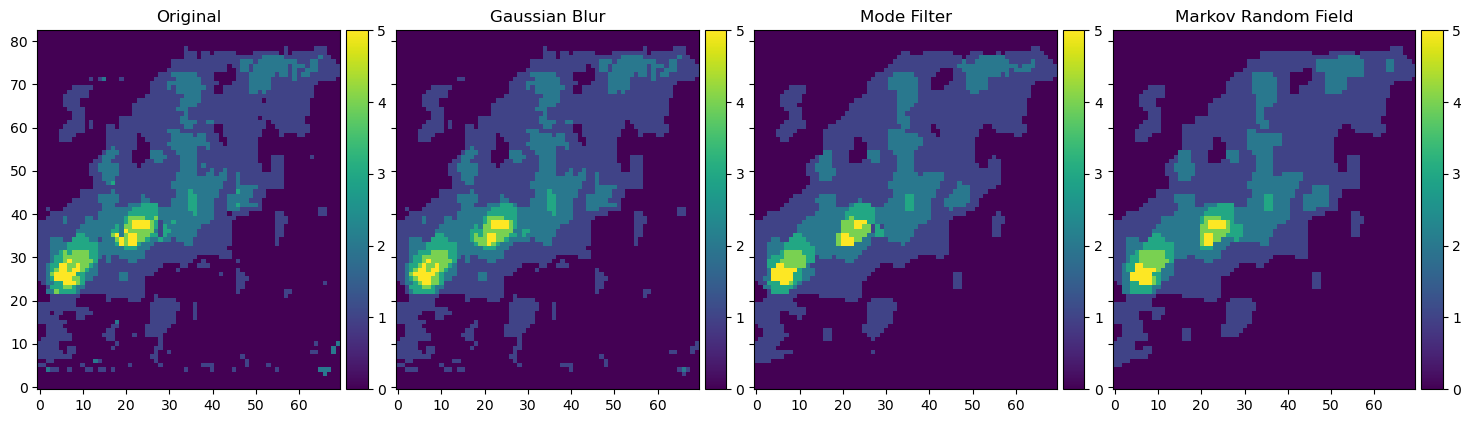

In [62]:
plot_smoothed_maps(**OIII_data)

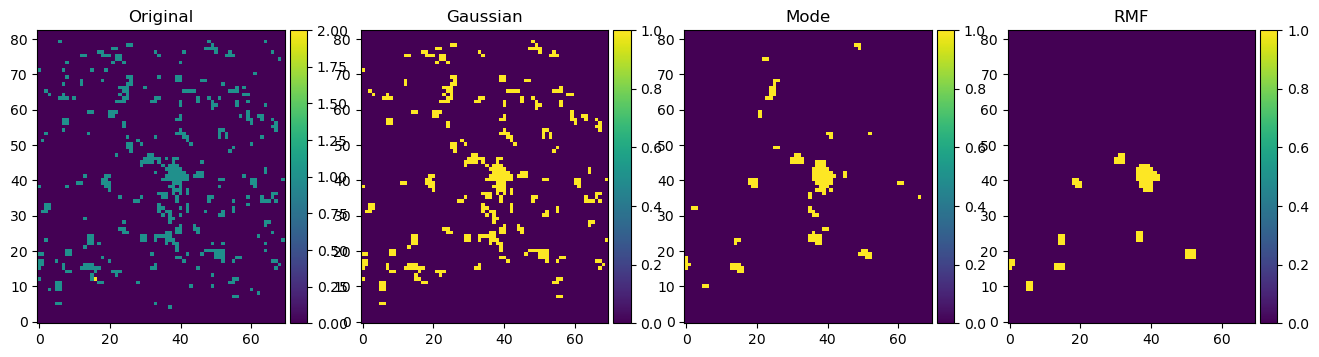

In [22]:
plot_smoothed_maps(**OII_data)

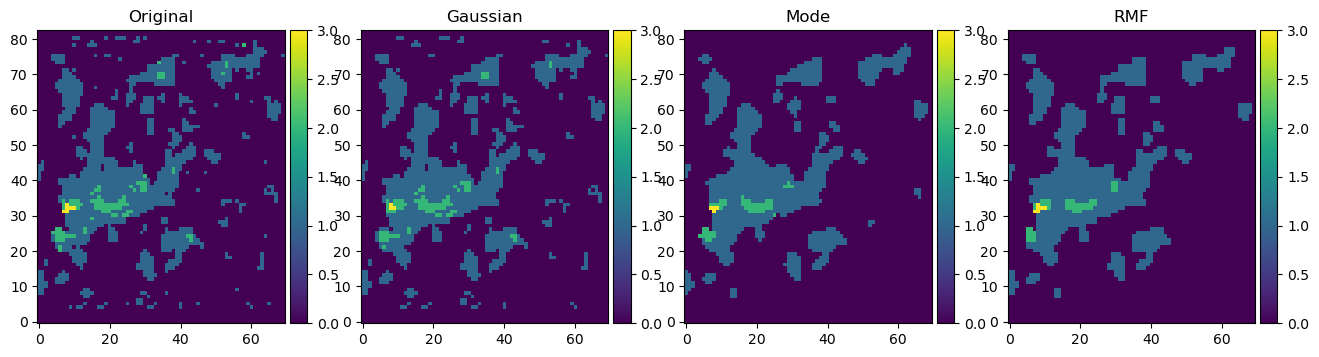

In [18]:
plot_smoothed_maps(**Halpha_data)

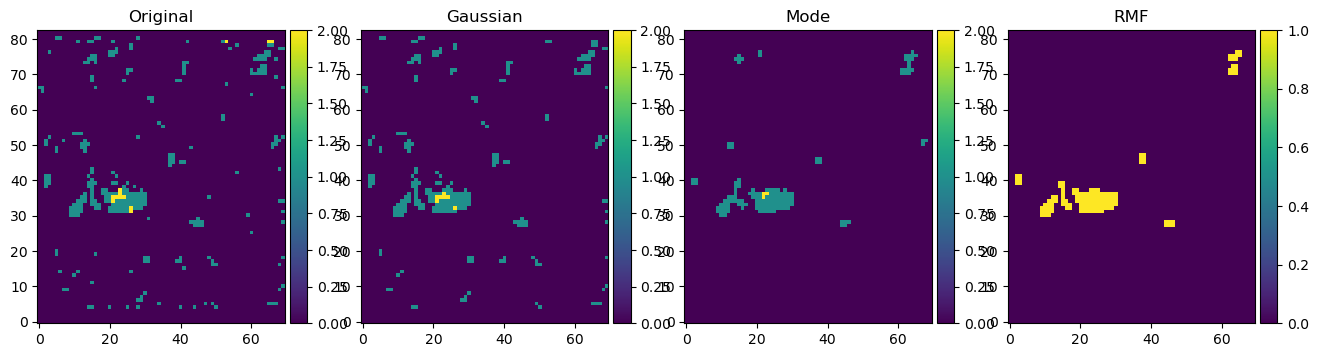

In [19]:
plot_smoothed_maps(**SII_data)

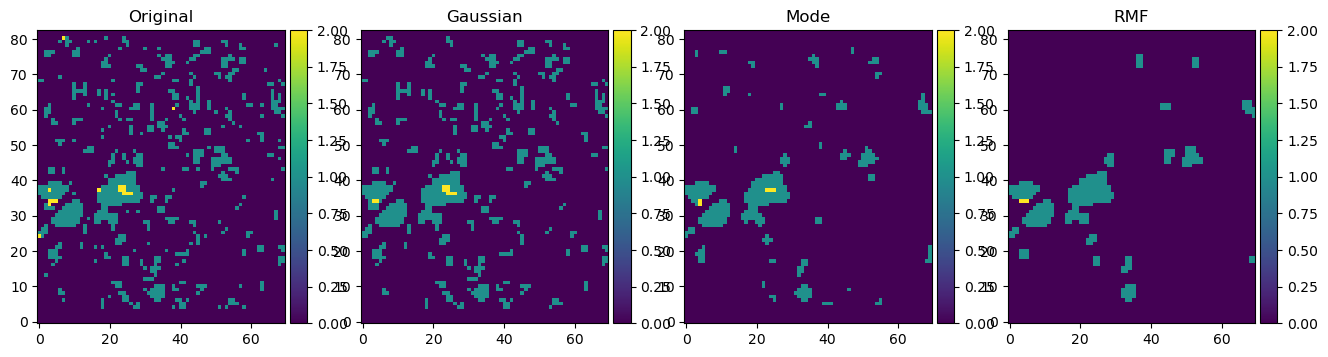

In [21]:
plot_smoothed_maps(**NeIII_data)

In [5]:
from q3dinterface import Q3DInterface
import tkinter as tk
window = tk.Tk()
# Q3DInterface(window, "/../../OIII/input/q3di_4C1971_from_OIII_binned", True, "")
Q3DInterface(window, "4C1971_neighbour_method", True, "")
def on_closing():
    window.quit()
    window.destroy()
window.protocol("WM_DELETE_WINDOW", on_closing)
window.mainloop()

/home/daniel/masterthesis/4C+1971/q3dinterface.py:817: RuntimeWarning: invalid value encountered in scalar divide
  snr = q3do.line_fitpars['flux'][line].data[i] / q3do.line_fitpars['fluxerr'][line].data[i]
/home/daniel/masterthesis/4C+1971/q3dinterface.py:817: RuntimeWarning: invalid value encountered in scalar divide
  snr = q3do.line_fitpars['flux'][line].data[i] / q3do.line_fitpars['fluxerr'][line].data[i]


<Figure size 640x480 with 0 Axes>